# Face Recognition con ArcFace

Deng, J., Guo, J., Xue, N., & Zafeiriou, S. (2019). [Arcface: Additive angular margin loss for deep face recognition](https://openaccess.thecvf.com/content_CVPR_2019/papers/Deng_ArcFace_Additive_Angular_Margin_Loss_for_Deep_Face_Recognition_CVPR_2019_paper.pdf). In Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (pp. 4690-4699).



## Librería ArcFace

In [1]:
!pip install arcface

## Imágenes de prueba

Las caras A y B son de la misma persona, la cara C es de otra persona

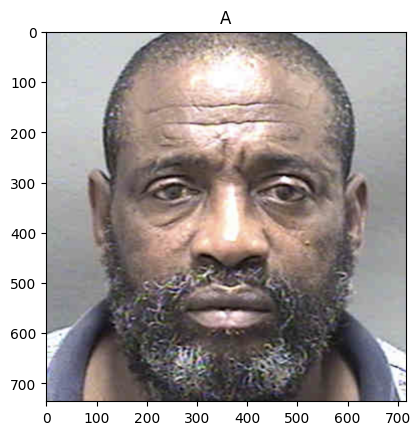

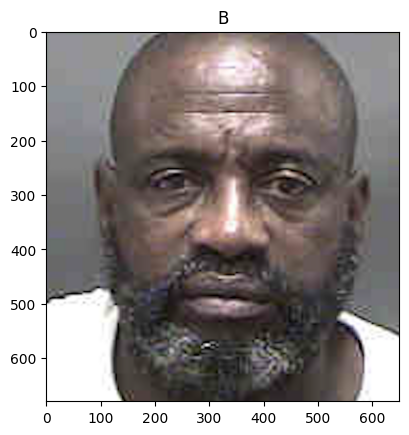

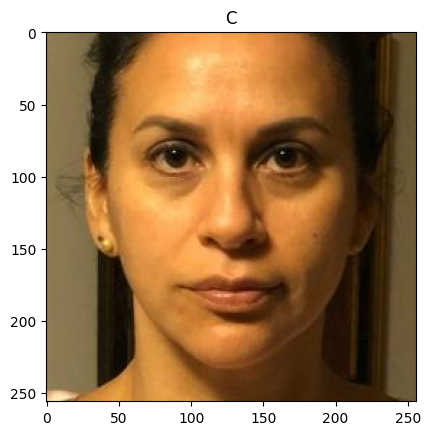

In [2]:
import cv2
import matplotlib.pyplot as plt


A = cv2.imread('faceA.png')
B = cv2.imread('faceB.png')
C = cv2.imread('faceC.jpg')

plt.imshow(cv2.cvtColor(A, cv2.COLOR_BGR2RGB))
plt.title('A')
plt.show()
plt.imshow(cv2.cvtColor(B, cv2.COLOR_BGR2RGB))
plt.title('B')
plt.show()
plt.imshow(cv2.cvtColor(C, cv2.COLOR_BGR2RGB))
plt.title('C')
plt.show()


## Cómputo de Embeddings

In [3]:
from arcface import ArcFace

In [8]:
!pip install deepface

In [9]:
from deepface import DeepFace

# Tus variables ya son las matrices de las imágenes (gracias a cv2.imread)
# DeepFace puede procesar estas matrices directamente

# Calculamos los embeddings

xA = DeepFace.represent(img_path=A, model_name="ArcFace", enforce_detection=False)[0]["embedding"]
xB = DeepFace.represent(img_path=B, model_name="ArcFace", enforce_detection=False)[0]["embedding"]
xC = DeepFace.represent(img_path=C, model_name="ArcFace", enforce_detection=False)[0]["embedding"]

print("¡Embeddings calculados con éxito!")

26-06-01 02:58:21 - Directory /root/.deepface has been created
26-06-01 02:58:21 - Directory /root/.deepface/weights has been created


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5
To: /root/.deepface/weights/arcface_weights.h5


26-06-01 02:58:25 - 🔗 arcface_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5 to /root/.deepface/weights/arcface_weights.h5...


100%|██████████| 137M/137M [00:01<00:00, 104MB/s] 


¡Embeddings calculados con éxito!


## Cómputo de Score usando similitud de coseno

In [10]:
import numpy as np

In [13]:
from numpy.linalg import norm
from scipy.spatial.distance import cosine

# 1. Función para normalizar (hace que todos los vectores tengan longitud 1)
def normalizar(v):
    return v / norm(v)

# 2. Normalizamos tus vectores
xA_n = normalizar(np.array(xA))
xB_n = normalizar(np.array(xB))
xC_n = normalizar(np.array(xC))

# 3. Calculamos la Similitud del Coseno (1 - distancia)
# Resultado: 1 = idéntico, 0 = nada parecido
score_AB = 1 - cosine(xA_n, xB_n)
score_AC = 1 - cosine(xA_n, xC_n)
score_BC = 1 - cosine(xB_n, xC_n)

print(f"Similitud Coseno (A,B): {score_AB:.4f}")
print(f"Similitud Coseno (A,C): {score_AC:.4f}")
print(f"Similitud Coseno (B,C): {score_BC:.4f}")

Similitud Coseno (A,B): 0.6419
Similitud Coseno (A,C): 0.0871
Similitud Coseno (B,C): 0.1117
